In [5]:
import pandas as pd
import xarray as xr
import os
import geopandas as gpd
import matplotlib.pyplot as plt

In [6]:
# Electricity demand ASEAN 
path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\ssp2-2.6\2030\era5_2018\Asia.csv"  # or Europe.nc etc.
countries = ["BN", "KH", "ID", "LA", "MY", "MM", "PH", "SG", "TH", "VN"]
# Load as pandas DataFrame since the file is CSV
ds = pd.read_csv(path,sep=';')

# If you want to filter by region_code using the countries list
ds_selected = ds[ds['region_code'].isin(countries)]

# Save the filtered DataFrame to CSV
ds_selected=ds_selected.set_index('time')
el_demand_asean=ds_selected.groupby('region_name').sum()['Electricity demand']
display(el_demand_asean) 
el_demand_asean.sum()/1e6 # Convert to TWh, asean 2050

region_name
Brunei         5.426202e+06
Cambodia       9.182338e+06
Indonesia      3.090736e+08
Laos           0.000000e+00
Malaysia       1.935340e+08
Myanmar        2.304582e+07
Philippines    1.132806e+08
Singapore      6.639179e+07
Thailand       2.757739e+08
Vietnam        2.112464e+08
Name: Electricity demand, dtype: float64

1206.9545497807856

In [7]:
# Renewable profiles
solar = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_solar.nc")
wind_on = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_onwind.nc")
wind_off_ac = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_offwind-ac.nc") 
wind_off_dc = xr.open_dataset(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\renewable_profiles\profile_offwind-dc.nc") 
wind = xr.Dataset({
    "onshore": wind_on["potential"],
    "offshore_ac": wind_off_ac["potential"],
    "offshore_dc": wind_off_dc["potential"]
})
wind["total_potential"] = wind.to_array(dim="source").sum(dim="source", skipna=True)
country_shape_data = gpd.read_file(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\shapes\country_shapes.geojson").set_index('name')
country_shape_data = country_shape_data.to_crs("EPSG:4326")

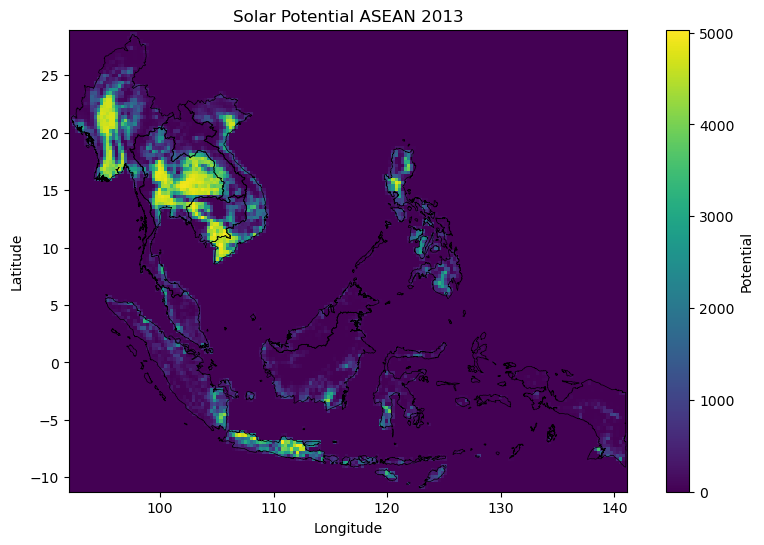

In [8]:

ds = solar  # already loaded
potential = ds['potential']
potential = potential.rio.write_crs("EPSG:4326")
# Plot
import numpy as np

# Get coordinate centers from xarray
x = ds['x'].values
y = ds['y'].values
z = ds['potential'].values

# Compute edges from centers
dx = (x[1] - x[0]) / 2
dy = (y[1] - y[0]) / 2
x_edges = np.concatenate([[x[0] - dx], x[:-1] + dx, [x[-1] + dx]])
y_edges = np.concatenate([[y[0] - dy], y[:-1] + dy, [y[-1] + dy]])

# Plot using imshow with correct extent
fig, ax = plt.subplots(figsize=(10, 6))
img = ax.imshow(
    z,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    cmap="viridis",
    aspect="auto"
)

# Overlay country borders
country_shape_data.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

# Colorbar + labels
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Potential")
plt.title("Solar Potential ASEAN 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



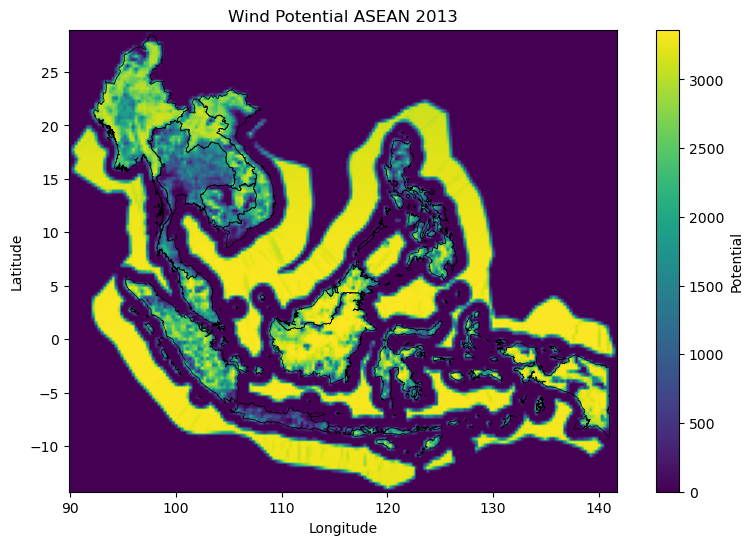

In [9]:

ds = wind  # already loaded
potential = ds  # ['potential']
potential = potential.rio.write_crs("EPSG:4326")
# Plot
import numpy as np

# Get coordinate centers from xarray
x = ds['x'].values
y = ds['y'].values

# Select one variable to plot, e.g., "onshore"
z = ds['total_potential'].values

# Compute edges from centers
dx = (x[1] - x[0]) / 2
dy = (y[1] - y[0]) / 2
x_edges = np.concatenate([[x[0] - dx], x[:-1] + dx, [x[-1] + dx]])
y_edges = np.concatenate([[y[0] - dy], y[:-1] + dy, [y[-1] + dy]])

# Plot using imshow with correct extent
fig, ax = plt.subplots(figsize=(10, 6))
img = ax.imshow(
    z,
    origin="lower",
    extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]],
    cmap="viridis",
    aspect="auto"
)

# Overlay country borders
country_shape_data.boundary.plot(ax=ax, edgecolor='black', linewidth=0.5)

# Colorbar + labels
cbar = plt.colorbar(img, ax=ax)
cbar.set_label("Potential")
plt.title("Wind Potential ASEAN 2018")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()



In [10]:
# other energy  
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\energy_totals_base.csv",sep=',')
ds = ds[ds["Unnamed: 0.1"].isin(countries)]
display(ds)
ds.columns
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/efficiency_gains_cagr.csv",sep=',')
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/growth_factors_cagr.csv",sep=',')
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/district_heating.csv",sep=',')
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/demand/fuel_shares.csv",sep=',')
display(ds)


,Unnamed: 0.1,Unnamed: 0,agriculture biomass,agriculture electricity,agriculture oil,electricity rail,electricity residential,residential biomass,residential gas,residential heat biomass,...,other electricity,other oil,other biomass,other gas,other heat,non energy electricity,non energy oil,non energy biomass,non energy gas,non energy heat
0,MY,NaN,0.0000,0.6639,10.2298,0.4778,31.5702,5.7866,0.0078,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,32.8993,0.0,139.8046,0.0
1,VN,NaN,4.4005,6.5954,10.9716,NaN,85.2952,2.7928,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,7.7632,0.0,8.3039,0.0
2,MM,NaN,0.0000,0.0000,16.0165,0.0000,8.0758,55.9500,0.0000,NaN,...,0.0000,0.3808,0.0,0.0000,0.0,0.0000,3.9765,0.0,1.9186,0.0
3,LA,NaN,0.0000,0.0419,0.3821,NaN,2.1358,9.8660,0.0000,NaN,...,0.9722,0.0000,0.0,0.0000,0.0,0.0000,0.0212,0.0,0.0000,0.0
4,TH,NaN,0.0000,0.4680,34.9603,0.2150,49.2020,31.4891,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,221.4579,0.0,53.7731,0.0
5,PH,NaN,0.0461,2.7900,2.8012,0.1062,30.5520,59.4536,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0380,9.9211,0.0,0.0000,0.0
6,KH,NaN,0.0000,0.0000,0.0036,0.0000,3.3996,7.9612,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,0.1545,0.0,0.0000,0.0
7,ID,NaN,0.0000,0.5940,4.3145,0.2780,104.7140,85.6952,0.2417,NaN,...,NaN,NaN,NaN,NaN,NaN,4.4999,26.2596,0.0,79.8011,0.0
8,BN,NaN,NaN,NaN,NaN,NaN,1.3287,0.0296,0.2333,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,1.5273,0.0,6.0653,0.0
9,SG,NaN,NaN,NaN,NaN,3.0193,7.6813,0.0000,0.7359,NaN,...,0.0000,0.0000,0.0,0.0415,0.0,0.0000,78.4750,0.0,0.0000,0.0


,Unnamed: 0,total residential space,total residential water,electricity residential,total services space,total services water,total rail,electricity rail,total domestic aviation,total international aviation,...,services biomass,services gas,total road ev,total road fcev,total road ice,total navigation oil,total navigation hydrogen,residential heat biomass,residential heat oil,residential heat gas
0,DEFAULT,-0.004951,-0.01039,-0.002696,-0.006705,-0.017864,-0.004951,-0.002146,0.0,0.0,...,-0.00553,0.0,-0.061401,-0.026527,0.0,-0.001063,-0.008517,-0.002696,-0.002696,0.0
1,MA,-0.004951,-0.01039,-0.002696,-0.006705,-0.017864,-0.004951,-0.002146,0.0,0.0,...,-0.00553,0.0,-0.061401,-0.026527,0.0,-0.001063,-0.008517,-0.002696,-0.002696,0.0
2,TN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN
3,US,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,...,0.00000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0


,Unnamed: 0,total residential space,total residential water,electricity residential,total services space,total services water,total road,total rail,electricity rail,total domestic aviation,...,residential oil,residential biomass,residential gas,agriculture biomass,services oil,services biomass,services gas,residential heat oil,residential heat biomass,residential heat gas
0,DEFAULT,0.02157,0.025046,0.055686,0.017867,0.02157,0.013904,0.049408,0.039822,0.037155,...,0.000,0.0000,0.010955,0.014719,-0.035824,0.0,-0.006115,0.000,0.0000,0.0000
1,MA,0.02157,0.025046,0.055686,0.017867,0.02157,0.013904,0.049408,0.039822,0.037155,...,0.000,0.0000,0.010955,0.014719,-0.035824,0.0,-0.006115,0.000,0.0000,0.0000
2,TN,0.02000,NaN,0.015000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,0.020000,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.053000,NaN,NaN,0.003800,NaN,0.000000,NaN,...,0.120,0.1540,0.045000,0.032000,NaN,NaN,NaN,NaN,NaN,NaN
4,US,0.00800,0.003900,0.009000,0.009000,0.01900,0.007600,0.001000,0.000000,0.025000,...,-0.022,-0.0071,-0.000800,0.000000,-0.007000,0.0,0.000000,-0.022,-0.0071,-0.0049


,country,current,potential
0,DEFAULT,0,0
1,MA,0,0
2,TN,0,0


,country,oil residential heat share,biomass residential heat share,biomass to elec heat share,oil to elec heat share,biomass to elec share,oil to elec share,space to water heat share,gas to elec share,gas to elec heat share,gas residential heat share
0,DEFAULT,0.6667,0.750,0.00,0.5,0.00,0.5,0.60,0.00,0.0,0.75
1,MA,0.6667,0.750,0.00,0.5,0.00,0.5,0.60,0.00,0.0,0.75
2,TN,0.0000,0.110,0.37,0.0,0.01,0.0,0.01,0.98,0.0,NaN
3,NaN,0.0250,0.017,0.76,NaN,NaN,NaN,0.00,0.00,0.0,NaN
4,US,0.8800,1.000,0.00,0.0,0.00,0.0,0.00,0.00,0.0,0.72


,country,number cars,average fuel efficiency
23,KH,3751715,0.364
65,ID,128398594,0.692
79,LA,1850020,0.677
87,MY,27613120,0.703
98,MM,6381136,0.634
114,PH,9251565,0.722
131,SG,933534,0.848
145,TH,37338139,0.753
159,VN,50666855,0.777
164,BN,475000,0.799


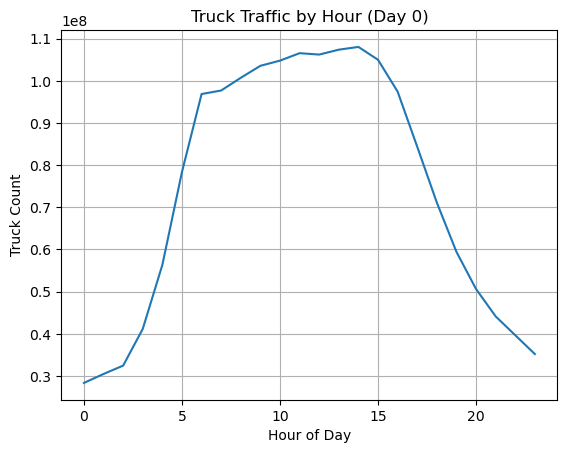

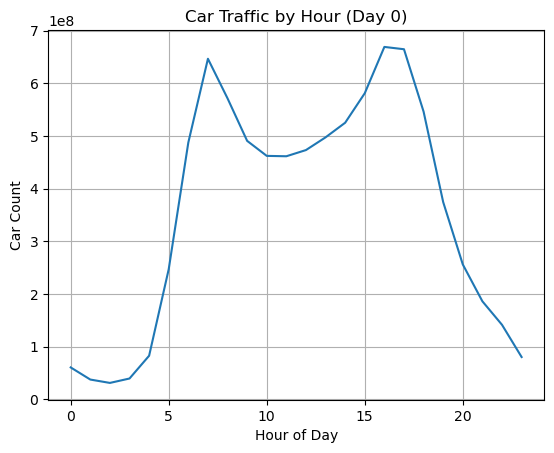

C:\Users\ffill\AppData\Local\Temp\ipykernel_7396\2016712255.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ds=ds.resample('H').mean()


TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [ ]:

# Transport data 
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\transport_data.csv",sep=',')
ds = ds[ds['country'].isin(countries)]
display(ds)
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\emobility\Lkw__count", skiprows=2)

df_day0 = ds[ds["day"] == 0]
plt.plot(df_day0["hour"], df_day0["count"])
plt.xlabel("Hour of Day")
plt.ylabel("Truck Count")
plt.title("Truck Traffic by Hour (Day 0)")
plt.grid(True)
plt.show()

ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\emobility\Pkw__count", skiprows=2)

df_day0 = ds[ds["day"] == 0]
plt.plot(df_day0["hour"], df_day0["count"])
plt.xlabel("Hour of Day")
plt.ylabel("Car Count")
plt.title("Car Traffic by Hour (Day 0)")
plt.grid(True)
plt.show()

ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\transport_AB_s_55_2030.csv",sep=',')
ds.set_index('snapshot', inplace=True)
ds=ds.resample('H').mean()
ds['total'] = ds.sum(axis=1)

ds[['total']].plot(figsize=(12, 5), linewidth=1.5)
plt.title("Total Transport Demand – ASEAN Regions (2030 Scenario)")
plt.xlabel("Timestamp")
plt.ylabel("Total Transport Demand (MWh or MW)")  # Adjust unit based on source
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\energy_totals_base.csv",sep=',')
ds = ds[ds["Unnamed: 0.1"].isin(countries)]
display(ds)
ds.columns

,Unnamed: 0.1,Unnamed: 0,agriculture biomass,agriculture electricity,agriculture oil,electricity rail,electricity residential,residential biomass,residential gas,residential heat biomass,...,other electricity,other oil,other biomass,other gas,other heat,non energy electricity,non energy oil,non energy biomass,non energy gas,non energy heat
0,MY,NaN,0.0000,0.6639,10.2298,0.4778,31.5702,5.7866,0.0078,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,32.8993,0.0,139.8046,0.0
1,LA,NaN,0.0000,0.0419,0.3821,NaN,2.1358,9.8660,0.0000,NaN,...,0.9722,0.0000,0.0,0.0000,0.0,0.0000,0.0212,0.0,0.0000,0.0
2,ID,NaN,0.0000,0.5940,4.3145,0.2780,104.7140,85.6952,0.2417,NaN,...,NaN,NaN,NaN,NaN,NaN,4.4999,26.2596,0.0,79.8011,0.0
3,MM,NaN,0.0000,0.0000,16.0165,0.0000,8.0758,55.9500,0.0000,NaN,...,0.0000,0.3808,0.0,0.0000,0.0,0.0000,3.9765,0.0,1.9186,0.0
4,BN,NaN,NaN,NaN,NaN,NaN,1.3287,0.0296,0.2333,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,1.5273,0.0,6.0653,0.0
5,PH,NaN,0.0461,2.7900,2.8012,0.1062,30.5520,59.4536,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0380,9.9211,0.0,0.0000,0.0
6,TH,NaN,0.0000,0.4680,34.9603,0.2150,49.2020,31.4891,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,221.4579,0.0,53.7731,0.0
7,KH,NaN,0.0000,0.0000,0.0036,0.0000,3.3996,7.9612,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,0.1545,0.0,0.0000,0.0
8,SG,NaN,NaN,NaN,NaN,3.0193,7.6813,0.0000,0.7359,NaN,...,0.0000,0.0000,0.0,0.0415,0.0,0.0000,78.4750,0.0,0.0000,0.0
9,VN,NaN,4.4005,6.5954,10.9716,NaN,85.2952,2.7928,0.0000,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0000,7.7632,0.0,8.3039,0.0


Index(['Unnamed: 0.1', 'Unnamed: 0', 'agriculture biomass',
       'agriculture electricity', 'agriculture oil', 'electricity rail',
       'electricity residential', 'residential biomass', 'residential gas',
       'residential heat biomass', 'residential heat gas',
       'residential heat oil', 'residential oil', 'services biomass',
       'services electricity', 'services gas', 'services oil',
       'total domestic aviation', 'total domestic navigation',
       'total international aviation', 'total international navigation',
       'total rail', 'total residential space', 'total residential water',
       'total road', 'total services space', 'total services water',
       'electricity residential space', 'electricity residential water',
       'district heat share', 'electricity services space',
       'electricity services water', 'road electricity', 'road gas',
       'road biomass', 'road oil', 'agriculture coal', 'other electricity',
       'other oil', 'other biomass', 'oth

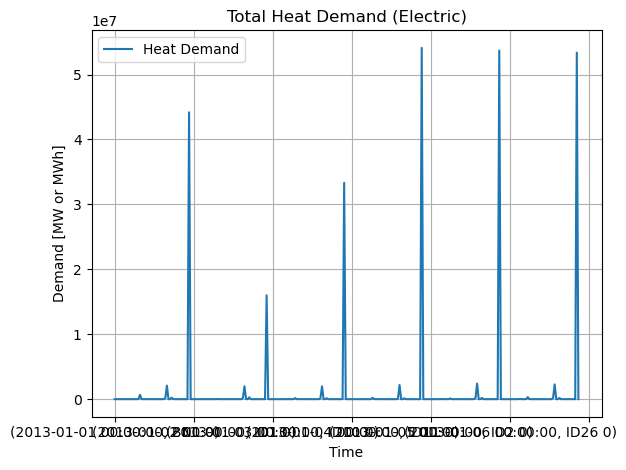

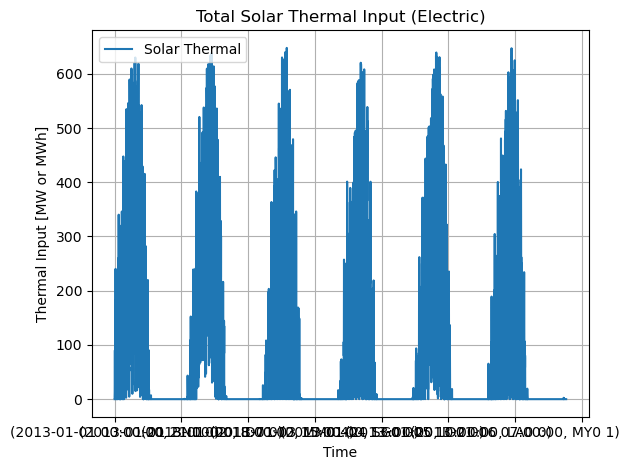

,Unnamed: 0,residential space weekday,residential space weekend,services space weekday,services space weekend,residential water weekday,residential water weekend,services water weekday,services water weekend
0,0,0.543784,0.539185,0.740230,0.791817,1.0,1.0,1.0,1.0
1,1,0.569050,0.564153,0.764203,0.792963,1.0,1.0,1.0,1.0
2,2,0.562402,0.557549,0.826442,0.896160,1.0,1.0,1.0,1.0
3,3,0.612035,0.607459,0.933848,1.066548,1.0,1.0,1.0,1.0
4,4,0.821009,0.818845,1.128809,1.277927,1.0,1.0,1.0,1.0


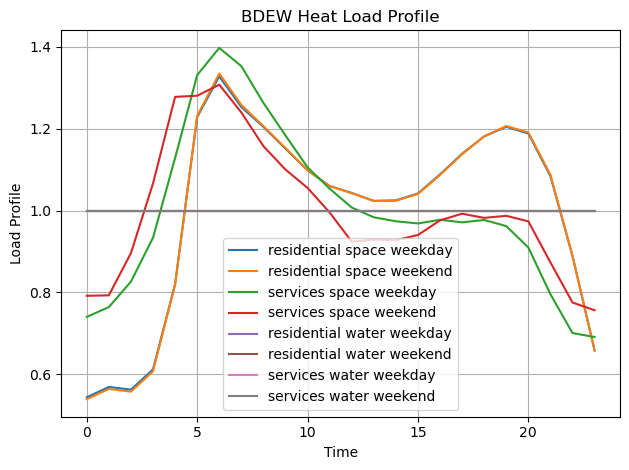

In [ ]:
# Heat demand 
heat_demand_path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\heat\heat_demand_total_elec_s_52_2030.nc"
ds_heat = xr.open_dataset(heat_demand_path)
ds_heat_total = ds_heat.to_dataframe().sum(axis=1)
ds_heat_total.plot(label='Heat Demand')
plt.title("Total Heat Demand (Electric)")
plt.xlabel("Time")
plt.ylabel("Demand [MW or MWh]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 2. Open and plot NetCDF: solar_thermal_total_elec_s_50_2030.nc ---
solar_path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand\heat\solar_thermal_total_elec_s_50_2030.nc"
ds_solar = xr.open_dataset(solar_path)

# Plot total solar thermal potential or input
ds_solar_total = ds_solar.to_dataframe().sum(axis=1)
ds_solar_total.plot(label='Solar Thermal')
plt.title("Total Solar Thermal Input (Electric)")
plt.xlabel("Time")
plt.ylabel("Thermal Input [MW or MWh]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# --- 3. Open and plot CSV: heat_load_profile_BDEW.csv ---
csv_path = r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data\heat_load_profile_BDEW.csv"
df_bdew = pd.read_csv(csv_path)
display(df_bdew.head())

# If the first column is time and rest are demand profiles:
df_bdew.set_index(df_bdew.columns[0], inplace=True)
df_bdew.plot(title="BDEW Heat Load Profile")
plt.xlabel("Time")
plt.ylabel("Load Profile")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\data/industrial_database.csv",sep=',')
display(ds[ds['country'].isin(countries)])
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\demand/base_industry_totals_2030_AB.csv",sep=',')
display(ds[ds['country'].isin(countries)])


,country,y,x,location,technology,capacity,unit,quality,ID
423,ID,-6.007021,106.001766,Cilegon,DRI + Electric arc,3075.0,kt/yr,exact,SID00003
424,ID,-5.998661,105.998660,Cilegon,Integrated steelworks,3000.0,kt/yr,exact,SID00004
425,ID,-2.829514,122.174896,Bahodopi,Integrated steelworks,3500.0,kt/yr,exact,SID00006
426,ID,-6.181643,106.932331,East Jakarta,Electric arc,900.0,kt/yr,exact,SID00002
427,ID,-3.339296,115.927125,unknown,Integrated steelworks,1000.0,kt/yr,exact,SID00005
...,...,...,...,...,...,...,...,...,...
4500,ID,-7.699630,109.000930,Jawa Tengah,HVC,348000.0,bpd,exact,160
4501,ID,-1.262700,116.816180,Kalimantan Timur,HVC,260000.0,bpd,exact,161
4502,ID,1.678460,101.472480,Riau,HVC,120000.0,bpd,exact,162
4503,ID,-2.978160,104.799440,Sumatera Selatan,HVC,50000.0,bpd,exact,163


,country,carrier,chemical and petrochemical,construction,food and tobacco,iron and steel,machinery,mining and quarrying,non-ferrous metals,non-metallic minerals,other,paper pulp and print,textile and leather,transport equipment,wood and wood products
90,BN,electricity,5.076590e+05,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000,0.000000e+00,2.015220e+05,0.000000e+00,0.000000e+00,0.0,0.000000e+00
91,BN,oil,1.216875e+05,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000,0.000000e+00,1.377004e+06,0.000000e+00,0.000000e+00,0.0,0.000000e+00
324,ID,biomass,3.317222e+05,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000,0.000000e+00,1.851703e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00
325,ID,coal,1.502053e+07,0.00,0.000000e+00,5.222230e+06,0.000000e+00,0.00,0.000000,0.000000e+00,2.693173e+08,0.000000e+00,0.000000e+00,0.0,0.000000e+00
326,ID,electricity,4.816000e+06,0.00,0.000000e+00,2.471000e+06,0.000000e+00,0.00,0.000000,0.000000e+00,8.103600e+07,0.000000e+00,0.000000e+00,0.0,0.000000e+00
327,ID,gas,8.362500e+06,0.00,0.000000e+00,3.076000e+07,0.000000e+00,0.00,0.000000,0.000000e+00,9.439944e+07,0.000000e+00,0.000000e+00,0.0,0.000000e+00
328,ID,oil,1.701331e+06,0.00,0.000000e+00,2.528271e+06,0.000000e+00,0.00,0.000000,0.000000e+00,9.098185e+07,0.000000e+00,0.000000e+00,0.0,0.000000e+00
385,KH,biomass,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000,0.000000e+00,2.487422e+06,0.000000e+00,0.000000e+00,0.0,0.000000e+00
386,KH,coal,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000,2.387443e+06,5.989060e+05,0.000000e+00,0.000000e+00,0.0,0.000000e+00
387,KH,electricity,0.000000e+00,0.00,0.000000e+00,0.000000e+00,0.000000e+00,0.00,0.000000,0.000000e+00,3.383290e+06,0.000000e+00,0.000000e+00,0.0,0.000000e+00


In [ ]:
#costs
ds = pd.read_csv(r"C:\Users\ffill\Documents\Uni\_TUBerlin\Master\Thesis\MA\pypsa-earth\pypsa-earth-project\pypsa-earth\resources\costs_2030.csv",sep=',')
display(ds)

,technology,parameter,value,unit,source,further description,currency_year
0,Ammonia cracker,FOM,4.300000e+00,%/year,Ishimoto et al. (2020): 10.1016/j.ijhydene.202...,"Estimated based on Labour cost rate, Maintenan...",2015.0
1,Ammonia cracker,ammonia-input,1.460000e+00,MWh_NH3/MWh_H2,ENGIE et al (2020): Ammonia to Green Hydrogen ...,Assuming a integrated 200t/d cracking and puri...,NaN
2,Ammonia cracker,investment,1.123945e+06,EUR/MW_H2,Ishimoto et al. (2020): 10.1016/j.ijhydene.202...,Calculated. For a small (200 t_NH3/d input) fa...,2015.0
3,Ammonia cracker,lifetime,2.500000e+01,years,Ishimoto et al. (2020): 10.1016/j.ijhydene.202...,NaN,2015.0
4,BEV Bus city,FOM,3.000000e-04,%/year,"Danish Energy Agency, inputs/data_sheets_for_c...",BEV B1,2022.0
...,...,...,...,...,...,...,...
1085,waste CHP CC,lifetime,2.500000e+01,years,"Danish Energy Agency, technology_data_for_el_a...","08 WtE CHP, Large, 50 degree: Technical lifetime",2015.0
1086,water pit charger,efficiency,8.367000e-01,per unit,"Danish Energy Agency, technology_data_catalogu...",: efficiency from sqr(Round trip efficiency),2015.0
1087,water pit discharger,efficiency,8.367000e-01,per unit,"Danish Energy Agency, technology_data_catalogu...",: efficiency from sqr(Round trip efficiency),2015.0
1088,water tank charger,efficiency,9.899000e-01,per unit,"Danish Energy Agency, technology_data_catalogu...",: efficiency from sqr(Round trip efficiency),2015.0


In [4]:
import xarray as xr

n = xr.open_dataset("../results/prenetworks/elec_s_105_ec_lcopt_Co2L0.05-EQ0.8c-3h_144h_2050_0.071_NZ_presec.nc")
print(list(n.variables))


['snapshots', 'snapshots_snapshot', 'snapshots_objective', 'snapshots_generators', 'snapshots_stores', 'investment_periods', 'investment_periods_objective', 'investment_periods_years', 'stores_i', 'stores_bus', 'stores_carrier', 'stores_e_nom_extendable', 'stores_e_cyclic', 'stores_capital_cost', 'links_i', 'links_num_parallel', 'links_v_nom', 'links_bus0', 'links_bus1', 'links_length', 'links_dc', 'links_geometry', 'links_bounds', 'links_carrier', 'links_type', 'links_s_max_pu', 'links_p_min_pu', 'links_p_nom', 'links_build_year', 'links_Unnamed: 0', 'links_index', 'links_underground', 'links_under_construction', 'links_country', 'links_underwater_fraction', 'links_project_status', 'links_tags', 'links_capital_cost', 'links_efficiency', 'links_p_nom_extendable', 'links_p_nom_min', 'links_down_time_before', 'links_min_down_time', 'links_min_up_time', 'links_up_time_before', 'storage_units_i', 'storage_units_carrier', 'storage_units_bus', 'storage_units_p_nom', 'storage_units_capital_co

In [5]:
ds=n.copy()
# Print all generator names
print(ds["generators_i"].values)

# Print all carriers
print(ds["generators_carrier"].values)

# Print the maximum installable capacity
print(ds["generators_p_nom_max"].values)

['BN4 0 CCGT' 'BN4 0 coal' 'BN4 0 onwind' 'BN4 0 solar' 'ID1 0 CCGT'
 'ID1 0 coal' 'ID1 0 geothermal' 'ID1 0 offwind-ac' 'ID1 0 offwind-dc'
 'ID1 0 oil' 'ID1 0 onwind' 'ID1 0 ror' 'ID1 0 solar' 'ID1 1 CCGT'
 'ID1 1 coal' 'ID1 1 geothermal' 'ID1 1 offwind-ac' 'ID1 1 offwind-dc'
 'ID1 1 oil' 'ID1 1 onwind' 'ID1 1 ror' 'ID1 1 solar' 'ID10 0 CCGT'
 'ID10 0 coal' 'ID10 0 offwind-ac' 'ID10 0 offwind-dc' 'ID10 0 onwind'
 'ID10 0 solar' 'ID10 1 offwind-ac' 'ID10 1 offwind-dc' 'ID10 1 onwind'
 'ID10 1 solar' 'ID11 0 offwind-ac' 'ID11 0 offwind-dc' 'ID11 0 onwind'
 'ID11 0 solar' 'ID11 1 offwind-ac' 'ID11 1 offwind-dc' 'ID11 1 onwind'
 'ID11 1 solar' 'ID12 0 CCGT' 'ID12 0 coal' 'ID12 0 offwind-ac'
 'ID12 0 offwind-dc' 'ID12 0 onwind' 'ID12 0 solar' 'ID12 1 offwind-ac'
 'ID12 1 offwind-dc' 'ID12 1 onwind' 'ID12 1 solar' 'ID2 0 CCGT'
 'ID2 0 coal' 'ID2 0 offwind-ac' 'ID2 0 offwind-dc' 'ID2 0 oil'
 'ID2 0 onwind' 'ID2 0 ror' 'ID2 0 solar' 'ID2 1 coal' 'ID2 1 offwind-ac'
 'ID2 1 offwind-dc' 'ID2 1 o